## 타깃이 없을 때 사용하는 머신러닝: 비지도 학습 (Unsupervised Learning)

- **비지도 학습**은 정답(타깃, 레이블)이 없은 데이터를 사용하는 머신러닝 방법입니다.

- 모델은 사람이 정답을 알려주지 않아도 데이터 속에서 **구조, 패턴, 유사성**을 스스로 찾아냅니다.

---

### 비지도 학습의 주요 목적

1. **비슷한 데이터끼리 묶기**

    → **군집화 (Clustering)**

2. **데이터의 핵심 구조를 더 단순하게 표현하기**

    → **차원 축소 (Dimensionality Reduction)**

---

### 예시

1. **사진 데이터 분석**

    정답 없이 사진들을 입력하면  
    → 색감, 형태, 질감이 비슷한 사진끼리 자동으로 그룹을 만듭니다.

2. **고객 데이터 분석**

    고객의 구매 정보를 분석하여  
    → 구매 패턴이 비슷한 고객 그룹을 자동으로 찾습니다.

---

### 비지도 학습의 대표적인 방법

1. **군집화 (Clustering)**  
비슷한 데이터끼리 자동으로 그룹을 만드는 방법

    예)
    - K-Means

2. **차원 축소 (Dimensionality Reduction)**  
데이터의 중요한 정보는 유지하면서 **특성 수를 줄이는 방법**

    예)
    - PCA (주성분 분석)

 ---
## 군집화 (Clustering)

군집화(Clustering)는 **정답 라벨 없이 데이터 간의 유사성을 기준으로 비슷한 샘플을 같은 그룹(클러스터)으로 묶는 비지도 학습 방법**입니다.

대부분의 군집 알고리즘은 **샘플 간 거리(distance)** 또는 **유사도(similarity)**를 기준으로 동작합니다.

- **거리 (distance)** : 두 데이터가 얼마나 떨어져 있는지를 나타내는 값
- **유사도 (similarity)** : 두 데이터가 얼마나 비슷한지를 나타내는 값

---

### 대표적인 거리 및 유사도 척도

| **척도 (Metric)** | **개념** | **수식 (Formula)** | **특징** |
| :--- | :--- | :--- | :--- |
| **유클리드 거리**<br>(Euclidean Distance) | 두 점 사이의 **직선 거리** | $d(\mathrm{x, y}) = \sqrt{\sum_{i=1}^n{(x_i-y_i)^2}}$ | 가장 많이 사용하는 거리 계산 방법 |
| **맨해튼 거리**<br>(Manhattan Distance) | **격자 형태**로 이동한 거리 | $d(\mathrm{x, y}) = \sum_{i=1}^n{\vert x_i-y_i \vert}$ | 큰 값(이상치)의 영향을 비교적 덜 받음 |
| **코사인 유사도**<br>(Cosine Similarity) | 벡터 간의 **각도**를 이용한 유사도 | $\mathrm{sim(x, y)}=\frac{\mathrm{x \cdot y}}{\mathrm{\vert x \vert y \vert}}$ | 문서나 텍스트 데이터의 유사도를 비교할 때 자주 사용 |

 ---
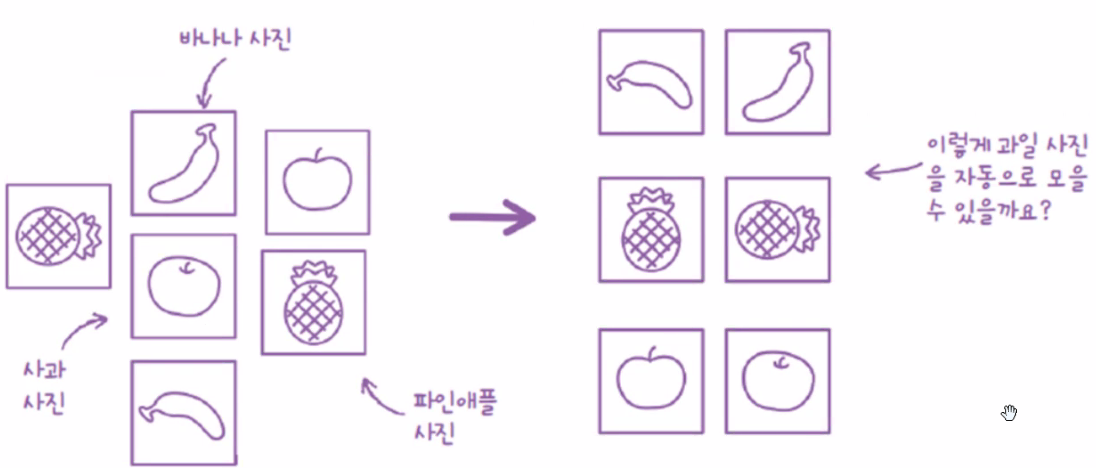

## 과일 사진 데이터 준비하기

- 사과, 바나나, 파인애플을 담고 있는 흑백 사진입니다.
- 이 데이터는 넘파이 배열의 기본 저장 포맷인 npy파일로 저장되어 있습니다.
- 이 과일 데이터는 캐글에서 공개된 데이터 셋입니다.  
https://www.kaggle.com/datasets/moltean/fruits

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fruits = np.load('data/fruits_300.npy')

In [3]:
print(fruits.shape)

(300, 100, 100)


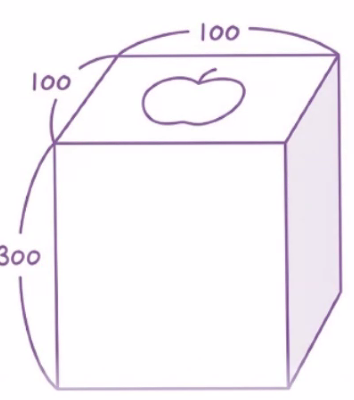

In [4]:
print(fruits[0, 0, :])

[  1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   2   1
   2   2   2   2   2   2   1   1   1   1   1   1   1   1   2   3   2   1
   2   1   1   1   1   2   1   3   2   1   3   1   4   1   2   5   5   5
  19 148 192 117  28   1   1   2   1   4   1   1   3   1   1   1   1   1
   2   2   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1   1
   1   1   1   1   1   1   1   1   1   1]


 ---
fruits 배열의 첫 번째 원소(이미지 데이터)를 선택하여 출력 준비를 합니다.

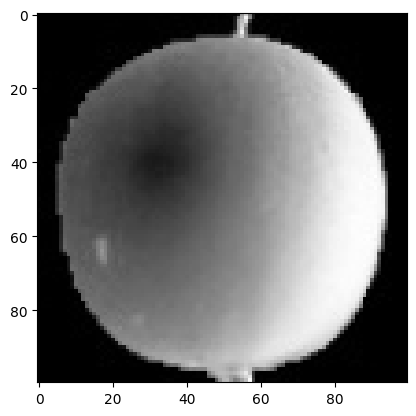

In [5]:
# cmap='gray'
# # cmap='gray' 설정을 통해 데이터를 흑백(grayscale) 지도로 매핑합니다.
# 배열의 값이 낮을수록 검은색, 높을수록 흰색으로 표시됩니다.
# 0 → 검은색, 255 → 흰색
plt.imshow(fruits[0], cmap='gray')
plt.show()

---
우리가 보기 편한 이미지로 색상 변환 합니다.

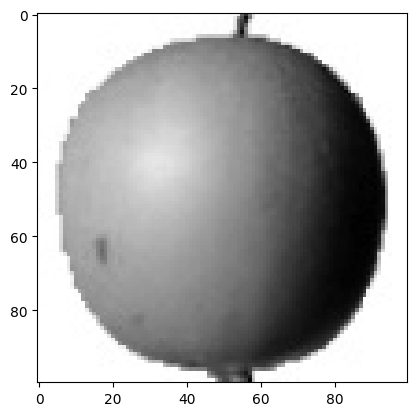

In [6]:
plt.imshow(fruits[0], cmap='gray_r')
plt.show()

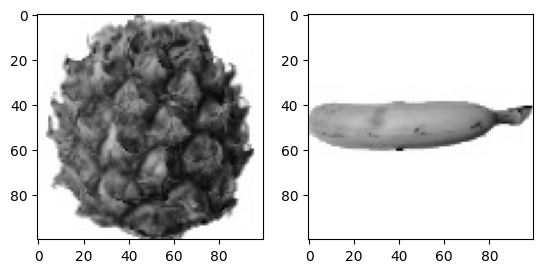

In [7]:
fig, axs = plt.subplots(1, 2)

axs[0].imshow(fruits[100], cmap='gray_r')
axs[1].imshow(fruits[200], cmap='gray_r')

plt.show()

 ---
## 문제

## fruits[99], fruits[199], fruits[299] 이미지 출력해 보세요

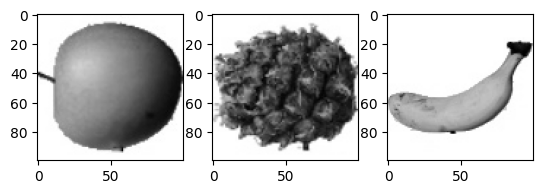

In [8]:
fig, axs = plt.subplots(1, 3)

axs[0].imshow(fruits[99], cmap='gray_r')
axs[1].imshow(fruits[199], cmap='gray_r')
axs[2].imshow(fruits[299], cmap='gray_r')

plt.show()

 ---
### 과일을 구분하기 위해 흑백 사진의 픽셀 값들의 평균을 구해 봅니다.

1. fruits.shape 가 (300, 100, 100)를 가지고 있습니다. 즉 3차원 배열입니다.

2. 머신러닝 모델들이 원하는 2차원 배열로 바꿔 보도록 하겠습니다.

## 픽셀 값 분석하기

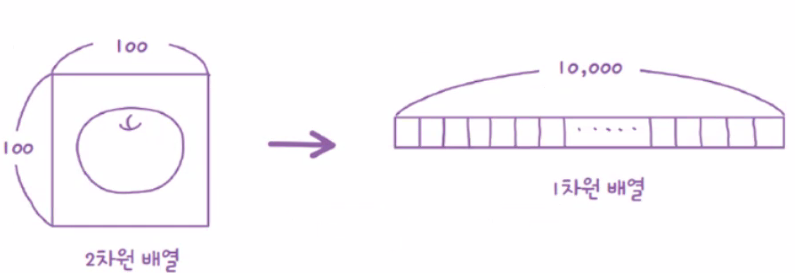

---
한 장의 이미지 (100, 100) -> (1, 10000) 으로 변경합니다.

In [9]:
# fruits[0] : 배열의 첫 번째 이미지
# reshape(-1, 100 * 100) : 배열의 차원을 새로 만듭니다. 행 자동 계산 x 10000열
apple0 = fruits[0].reshape(-1, 100 * 100)
print(apple0.shape)
print(apple0)

apple1 = fruits[1].reshape(-1, 100 * 100)
print(apple1.shape)
print(apple1)

apple2 = fruits[2].reshape(-1, 100 * 100)
print(apple2.shape)
print(apple2)

apple_0_1_2 = np.concatenate([apple0, apple1, apple2], axis=0)
print(apple_0_1_2.shape)
print(apple_0_1_2)

(1, 10000)
[[1 1 1 ... 1 1 1]]
(1, 10000)
[[1 1 1 ... 1 1 1]]
(1, 10000)
[[1 1 1 ... 1 1 1]]
(3, 10000)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


 ---
100장의 사과 데이터를 (100, 100) -> (1, 10000)으로 변경하기

In [10]:
apple = fruits[:100].reshape(-1, 100 * 100)

 ---
파인애플과 바나나 데이터를 (100, 100) -> (1, 10000)으로 변경하기

In [11]:
pineapple = fruits[100:200].reshape(-1, 100 * 100)
banana = fruits[200:300].reshape(-1, 100 * 100)

In [12]:
print(apple.shape)

(100, 10000)


 ---
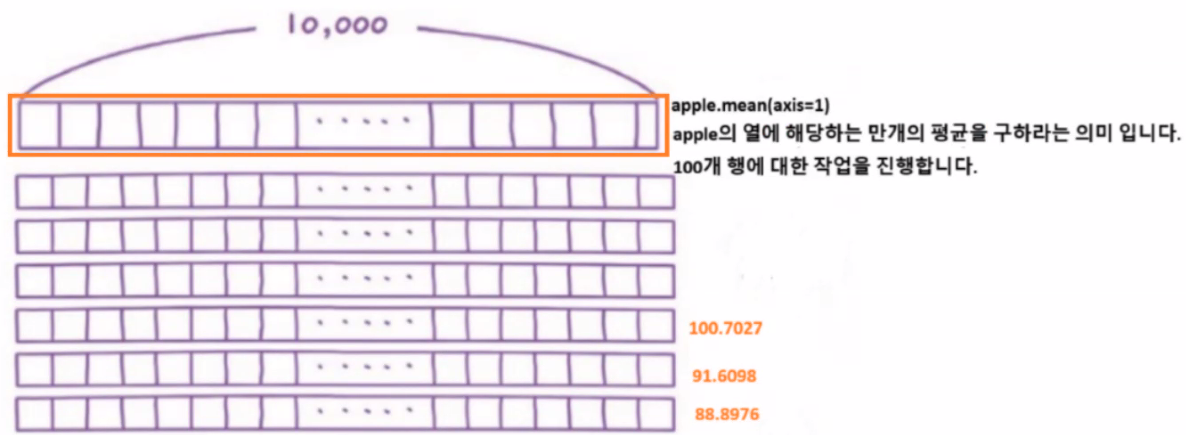

In [13]:
print(apple.mean(axis=1)) # 행 별로 평균 구하기 (10000개 픽셀값 평균 * 100장)

[ 88.3346  97.9249  87.3709  98.3703  92.8705  82.6439  94.4244  95.5999
  90.681   81.6226  87.0578  95.0745  93.8416  87.017   97.5078  87.2019
  88.9827 100.9158  92.7823 100.9184 104.9854  88.674   99.5643  97.2495
  94.1179  92.1935  95.1671  93.3322 102.8967  94.6695  90.5285  89.0744
  97.7641  97.2938 100.7564  90.5236 100.2542  85.8452  96.4615  97.1492
  90.711  102.3193  87.1629  89.8751  86.7327  86.3991  95.2865  89.1709
  96.8163  91.6604  96.1065  99.6829  94.9718  87.4812  89.2596  89.5268
  93.799   97.3983  87.151   97.825  103.22    94.4239  83.6657  83.5159
 102.8453  87.0379  91.2742 100.4848  93.8388  90.8568  97.4616  97.5022
  82.446   87.1789  96.9206  90.3135  90.565   97.6538  98.0919  93.6252
  87.3867  84.7073  89.1135  86.7646  88.7301  86.643   96.7323  97.2604
  81.9424  87.1687  97.2066  83.4712  95.9781  91.8096  98.4086 100.7823
 101.556  100.7027  91.6098  88.8976]


 ---
히스토그램 : 값이 발생한 빈도를 그래프로 표시한 것

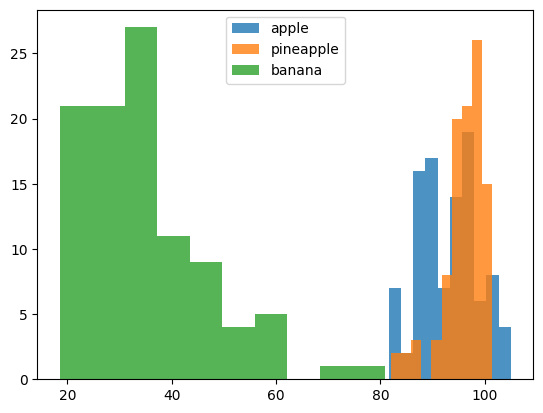

In [14]:
plt.hist(np.mean(apple, axis=1), alpha=0.8)
plt.hist(np.mean(pineapple, axis=1), alpha=0.8)
plt.hist(np.mean(banana, axis=1), alpha=0.8)
plt.legend(['apple', 'pineapple', 'banana'])
plt.show()
# 바나나는 40 아래에 집중되어 있습니다.
# 사과와 파인애플은 90~100 사이에 많이 모여 있습니다.
# 둘은 겹쳐져서 픽셀값만으로는 구분이 쉽지 않습니다.
# 둘의 형태가 모두 동그랗고 사진에서 차지하는 크기도 비슷하기 때문입니다.

 ---
각 픽셀 위치에 대한 평균값을 구해 봅시다.

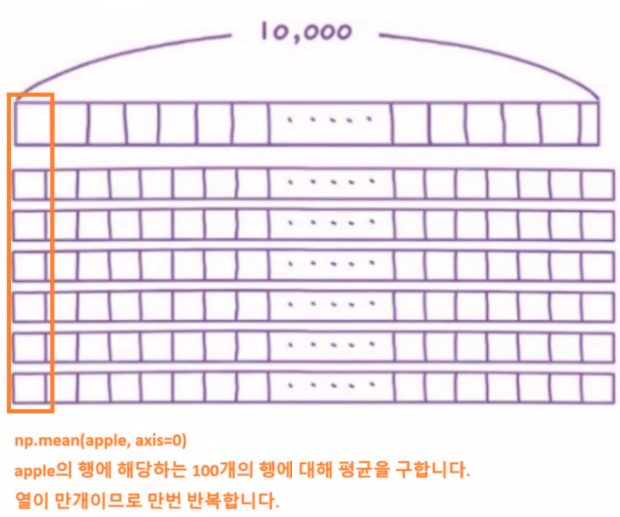

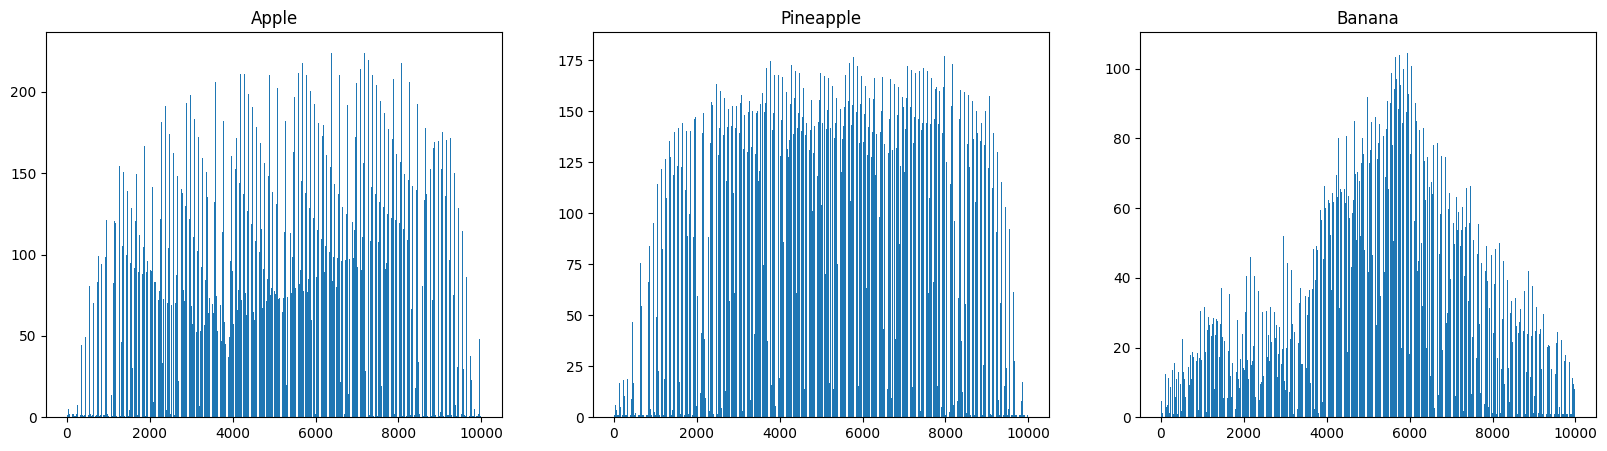

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

axs[0].bar(range(10000), np.mean(apple, axis=0))
axs[1].bar(range(10000), np.mean(pineapple, axis=0))
axs[2].bar(range(10000), np.mean(banana, axis=0))

axs[0].set_title('Apple')
axs[1].set_title('Pineapple')
axs[2].set_title('Banana')
plt.show()

## 과일 데이터셋 픽셀 평균 분석

공개된 과일 데이터셋($100 \times 100$)을 1차원 배열(10,000개 픽셀)로 펼친 뒤, 각 픽셀 위치별 **평균 밝기값**을 시각화한 결과입니다.

---

### 1. 그래프 구성 요소 및 연산

- **가로축 (0 ~ 10,000):** $100 \times 100$ 크기의 이미지를 한 줄로 펼쳤을 때의 **픽셀 위치**입니다.
- **세로축:** 해당 픽셀 위치에서 100개 샘플의 **평균 밝기값**을 나타냅니다.
- **데이터 처리:** `np.mean(apple, axis=0)`은 100개의 사과 이미지 데이터에서 동일한 좌표의 픽셀끼리 더해 평균을 낸 값입니다.

---

### 2. 과일별 시각화 특징

#### **(1) Apple (사과)**

- **특징:**
    - 사과는 대체로 둥근 형태입니다.
    - 이미지 중앙 근처에 위치하는 경우가 많습니다.

- **그래프 양상:**
    - 이미지의 중앙 부분(픽셀 번호 2,000 ~ 8,000 사이)에서 픽셀 값이 완만하게 높아지는 **산 모양**을 그립니다.
    - 가장자리로 갈수록 밝기 값이 낮아지는 경향이 있습니다.
    - 전체적으로 완만하게 솟아오른 산 모양의 분포를 보입니다.
    - 이러한 형태가 나타나는 이유는 이미지 중앙에는 사과가 위치하고 가장자리에는 배경이 포함되는 경우가 많기 때문입니다.

#### **(2) Pineapple (파인애플)**

- **특징:**
    - 파인애플은 밝은 노란색 계열의 색상이 많습니다.
    - 표면 질감이 거칠고 뾰족한 잎사귀가 포함되어 있습니다.
    - 이미지에서 과일이 차지하는 영역이 비교적 넓습니다.

- **그래프 양상:**
    - 전체 구간에서 비교적 높은 밝기 값이 넓게 분포합니다.
    - 파인애플은 사과보다 더 밝은 색이 많고, 표면이 복잡해서 그래프 윗부분이 빈틈없이 삐죽삐죽하게 채워져 있습니다.
    - 픽셀 값의 변화가 크고, 사과보다 밝은 값을 가진 픽셀이 더 넓게 분포합니다.
    - 세 과일 중에서 전체적으로 가장 밝은 그래프가 나타납니다.

#### **(3) Banana (바나나)**

- **특징:**
    - 가늘고 길쭉한 형태를 가집니다.
    - 이미지 중앙에 위치하는 경우가 많습니다.

- **그래프 양상:**
    - 특정 위치(약 6,000번 픽셀 근처)에서 밝기 값이 크게 증가합니다.
    - 양쪽 가장자리로 갈수록 값이 낮아집니다.
    - 전체적으로 가운데가 높고 양쪽이 낮은 종 모양 분포를 보입니다.
    - 이러한 형태가 나타나는 이유는 중앙에는 바나나가 있고 양쪽에는 배경이 많기 때문입니다.

 ---
사과, 파인애플, 바나나의 픽셀을 평균낸 이미지 만들기

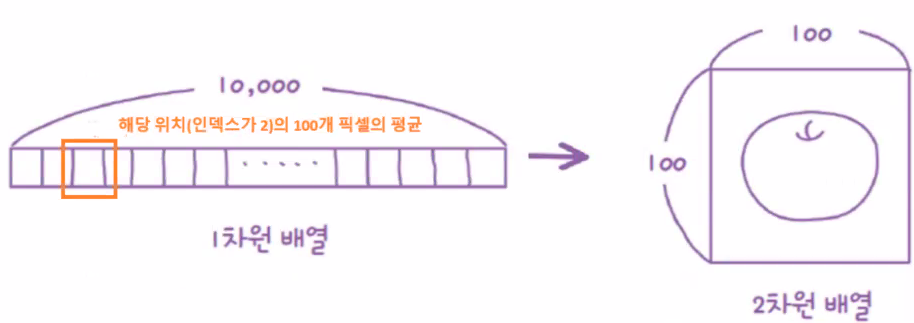

(10000,)


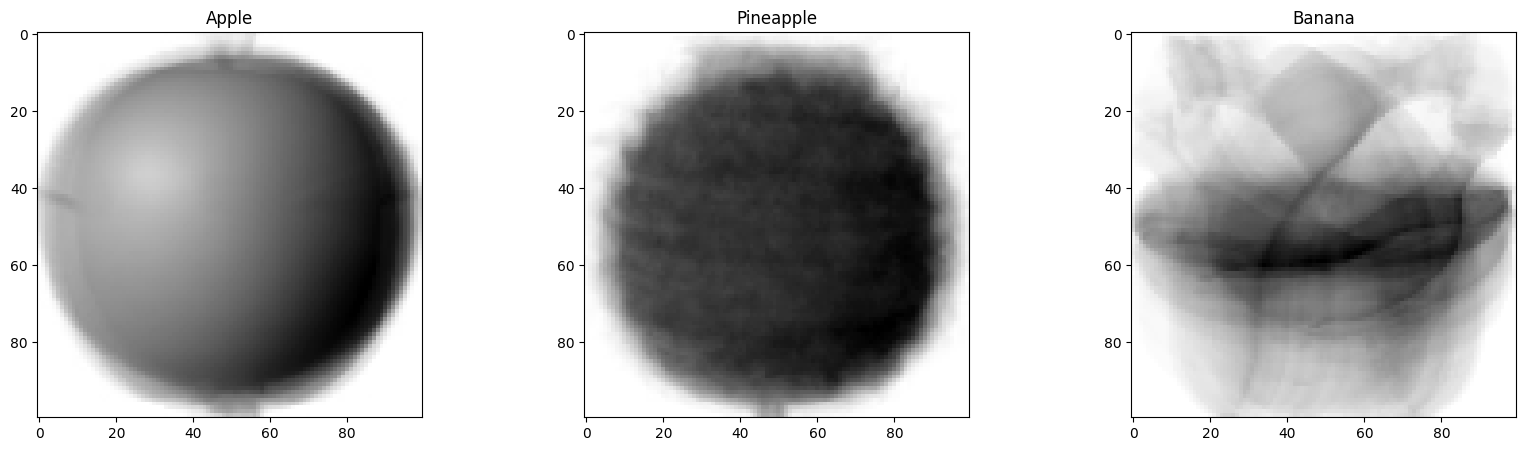

In [35]:
print(np.mean(apple, axis=0).shape)

apple_mean = np.mean(apple, axis=0).reshape(100, 100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100, 100)
banana_mean = np.mean(banana, axis=0).reshape(100, 100)

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap='gray_r')

axs[0].set_title('Apple')
axs[1].set_title('Pineapple')
axs[2].set_title('Banana')

plt.show()

 ---
## 평균과 비슷한 사진 고르기

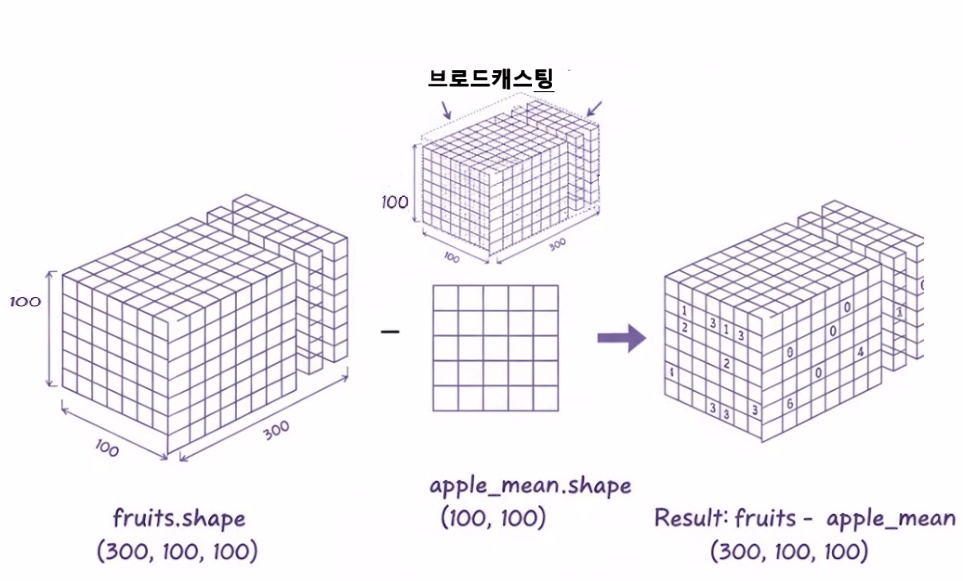

- fruits.shape : (300, 100, 100)

- apple_mean.shape : (100, 100)

- fruits - apple_mean는 NumPy의 브로드캐스팅이 적용됩니다.

    - 브로드캐스팅으로 apple_mean이 (300, 100, 100) 형태로 자동 확장된 것처럼 계산됩니다.
    - 즉, 모든 이미지에서 "평균 사과 이미지"를 빼는 연산입니다.
    - 결과 shape은 (300, 100, 100) 입니다.
    - 각 픽셀마다 "현재 이미지 픽셀값 - 평균 사과 이미지 픽셀값" 차이를 계산합니다.

In [36]:
# np.abs(fruits - apple_mean)는 각 픽셀 별 차이의 절댓값
# 각 이미지가 평균 사과 이미지와 얼마나 다른지를 계산합니다.
abs_diff = np.abs(fruits - apple_mean)
print(abs_diff.shape)

(300, 100, 100)


In [37]:
# axis = (1, 2) → 1은 행, 2는 열을 의미합니다.
# abs_diff, axis=(1, 2) 는 (300, 100, 100) 에서 행과 열인 (100, 100)을 의미합니다.
# np.mean(abs_diff, axis=(1, 2))는 abs_diff의 각 이미지의 가로(행) 세로(열)의 모든 픽셀에 대한 평균을 구합니다.
# 즉, 100x100 픽셀의 차이값들을 모두 더해 하나의 평균값으로 만듭니다.
abs_mean = np.mean(abs_diff, axis=(1, 2))
print(abs_mean)
print(abs_mean.shape) # 300개 원소의 1차원 배열

[17.37576  13.508874 17.183394 15.68311  17.983306 20.565392 16.795812
 16.144276 19.611994 21.32059  16.454222 16.590134 13.37039  17.23263
 15.92806  15.496638 18.582212 16.48196  27.651556 19.7871   20.826912
 16.417934 17.059946 15.904296 15.086176 19.371364 24.076362 14.777732
 19.20517  20.805182 14.797906 18.658418 15.973216 13.04259  18.381052
 16.59904  16.288504 18.960586 13.88574  16.497594 18.40376  19.174642
 29.096702 18.40849  28.223962 21.42994  19.740466 15.590532 13.082678
 18.765996 14.391198 21.464746 26.261028 15.887148 18.568706 16.410426
 17.108034 13.178824 18.199846 13.503056 20.845032 16.898184 22.81774
 18.99896  19.102706 16.636216 14.845644 19.357872 14.778086 14.468082
 13.085526 15.946606 20.42774  16.241996 13.720382 18.416166 15.229106
 16.411342 13.47148  20.050622 17.296816 21.071312 18.451708 19.645494
 15.585712 20.582004 13.850318 13.269222 21.875262 17.152098 15.60477
 23.890138 14.442124 18.794826 15.750524 16.58135  19.375552 17.802096
 15.47841

 ---
사과 평균 이미지와 가장 비슷한 이미지 100장을 화면에 보여 줍니다.

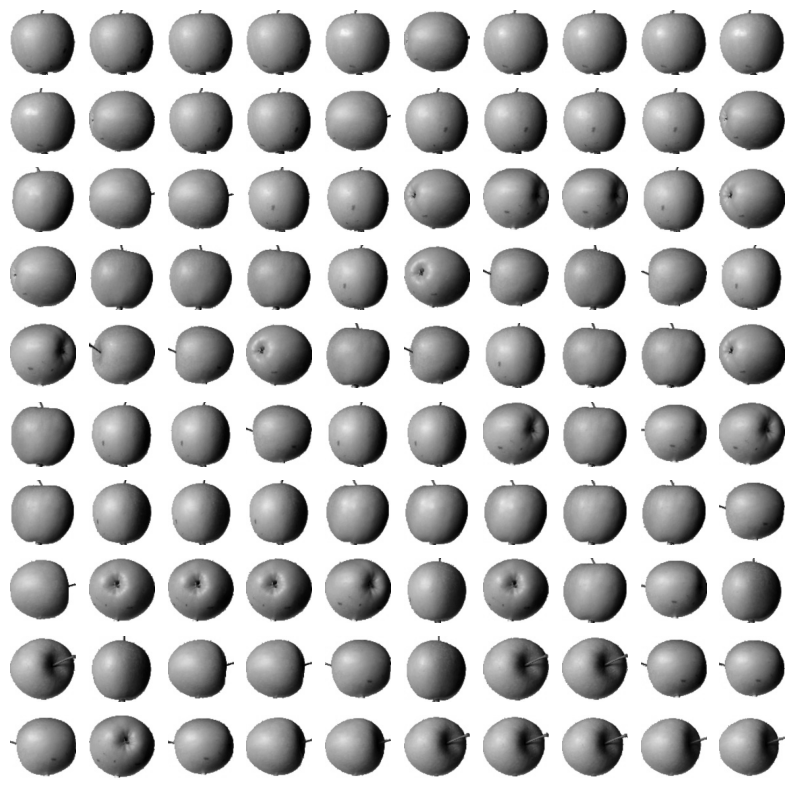

In [39]:
# np.argsort(abs_mean) : 배열을 오름차순으로 정렬했을 때 "원래 배열의 인덱스 위치"를 반환합니다.
# # [:100]: 정렬된 인덱스 중 앞에서부터 100개(차이가 가장 작은 것들)만 슬라이싱합니다.
apple_index = np.argsort(abs_mean)[:100]

fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10):
    for j in range(10):

        # apple_index에 저장된 인덱스를 사용하여 원본 fruits 배열에서 이미지를 가져옵니다.
        # cmap='gray_r': 흑백 반적(reverse) 모드입니다. (0: 흰색, 255: 검은색)
        axs[i, j].imshow(fruits[apple_index[i*10 + j]], cmap='gray_r')

        # 그래프의 눈금(축) 제거하여 이미지만 깔끔하게 보이도록 합니다.
        axs[i, j].axis('off')
plt.show()